/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_84581/2997807642.py:21: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, 'bool8'):


Environment: LunarLander-v3
State size: 8
State features: [x, y, vx, vy, angle, angular_velocity, left_leg_contact, right_leg_contact]
Base actions: [0, 1, 2] (Left, Right - symmetric stabilization)
Expand actions: [3] (Nothing, Main - efficiency + landing)
Full action list: [0, 1, 2, 3]
Mode: full

PHASE 1: Pre-training base model with 2 actions
Episode 10/200, Reward: -240.72, Steps: 82, Epsilon: 0.683
Episode 20/200, Reward: -67.50, Steps: 81, Epsilon: 0.261
Episode 30/200, Reward: -170.71, Steps: 96, Epsilon: 0.082
Episode 40/200, Reward: -99.82, Steps: 72, Epsilon: 0.050
Episode 50/200, Reward: -94.32, Steps: 91, Epsilon: 0.050
Episode 60/200, Reward: -218.01, Steps: 85, Epsilon: 0.050
Episode 70/200, Reward: -140.29, Steps: 274, Epsilon: 0.050
Episode 80/200, Reward: -159.62, Steps: 89, Epsilon: 0.050
Episode 90/200, Reward: -1.48, Steps: 126, Epsilon: 0.050
Episode 100/200, Reward: 236.49, Steps: 310, Epsilon: 0.050
Episode 110/200, Reward: -182.28, Steps: 83, Epsilon: 0.050
Epi

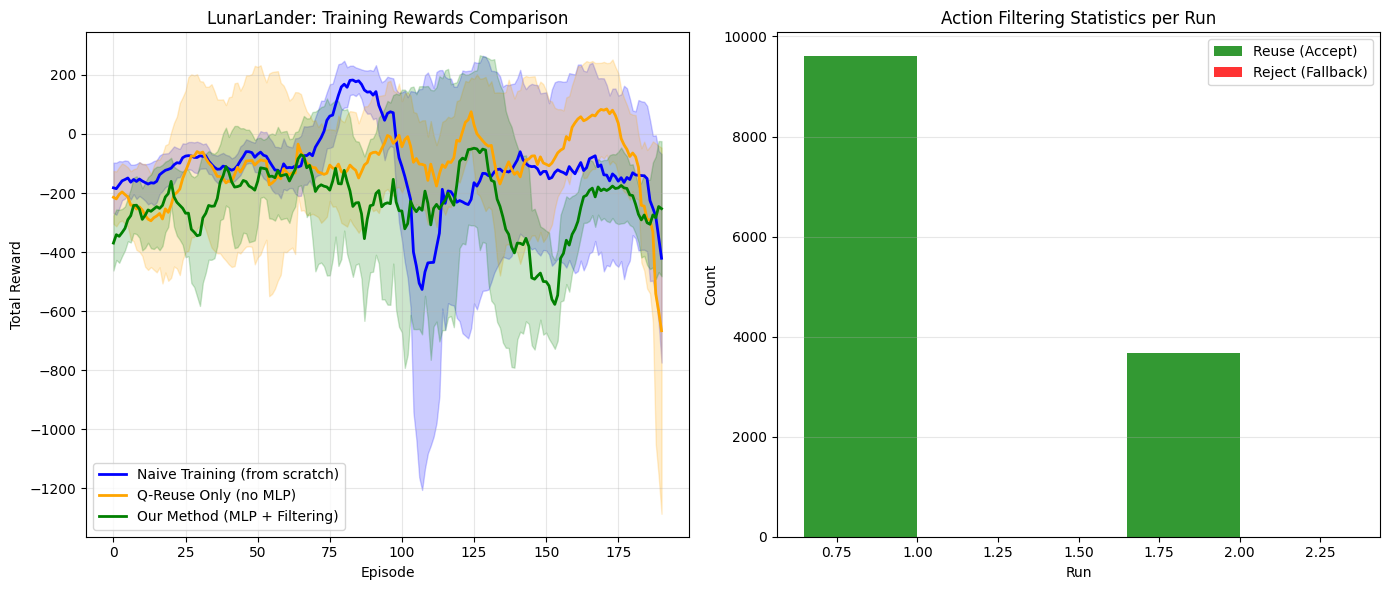


SUMMARY STATISTICS

1. Naive Training (from scratch):
   Final reward (mean ± std): -964.76 ± 707.30
   Max reward achieved: 282.18

2. Q-Reuse Only (weight reuse, no MLP):
   Final reward (mean ± std): -455.63 ± 642.94
   Max reward achieved: 214.89

3. Our Method (weight reuse + MLP + TD-gating):
   Final reward (mean ± std): -215.14 ± 179.32
   Max reward achieved: 101.67

------------------------------------------------------------
IMPROVEMENT ANALYSIS
------------------------------------------------------------
  Weight Reuse contribution:    +509.14 (+52.8%)
  TD-Gating contribution:       +240.49 (+24.9%)
  Total improvement:            +749.62 (+77.7%)

------------------------------------------------------------
TD-ERROR GATING STATISTICS (Theorem 1.6 & 1.7)
------------------------------------------------------------
  Total Accept (Reuse):     6633.50 ± 2969.50
    - High TD Error (τ):    4190.50 ± 556.50
    - Value Acceptable (η): 2443.00 ± 2413.00
  Total Reject (Fallbac

In [2]:
"""
Model-based Adaptation to Expanding Action Spaces in Reinforcement Learning
LunarLander Version - Better transition predictability for MLP model

Environment: LunarLander-v3
- State: 8 features (position, velocity, angle, leg contact)
- Actions: 4 (nothing, left engine, main engine, right engine)
- Deterministic physics - highly predictable transitions

Action Space Expansion:
- Base actions: [0, 2] - Nothing, Main engine (basic control)
- Expand actions: [1, 3] - Left engine, Right engine (fine control)
"""

import sys
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# =============================================================================
# DQN Network Architecture
# =============================================================================

class DQNNetwork(nn.Module):
    """Deep Q-Network with 3 hidden layers"""
    def __init__(self, state_size, action_size):
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, action_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


# =============================================================================
# Base DQN Agent (for pre-training with limited actions)
# =============================================================================

class DQNAgent:
    """DQN Agent for training with a fixed action set"""
    def __init__(self, state_size, action_list):
        self.state_size = state_size
        self.action_list = action_list
        self.action_to_idx = {action: idx for idx, action in enumerate(action_list)}
        self.memory = []
        self.max_memory_size = 20000
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.999  # Slower decay for better exploration
        self.learning_rate = 0.001
        self.batch_size = 128
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = DQNNetwork(self.state_size, len(self.action_list)).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()

    def remember(self, state, action_idx, reward, next_state, done):
        self.memory.append((state, action_idx, reward, next_state, done))
        if len(self.memory) > self.max_memory_size:
            self.memory.pop(0)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            action_idx = np.random.randint(len(self.action_list))
        else:
            state_tensor = torch.FloatTensor(state).to(self.device)
            self.model.eval()
            with torch.no_grad():
                q_values = self.model(state_tensor)
            self.model.train()
            action_idx = torch.argmax(q_values[0]).item()
        
        return self.action_list[action_idx], action_idx

    def replay(self, batch_size):
        minibatch = np.random.choice(len(self.memory), batch_size, replace=False)
        states = np.array([self.memory[i][0].flatten() for i in minibatch])
        actions = np.array([self.memory[i][1] for i in minibatch])
        rewards = np.array([self.memory[i][2] for i in minibatch])
        next_states = np.array([self.memory[i][3].flatten() for i in minibatch])
        dones = np.array([self.memory[i][4] for i in minibatch])

        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.LongTensor(actions).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        dones_tensor = torch.FloatTensor(dones).to(self.device)

        self.model.eval()
        with torch.no_grad():
            next_q_values = self.model(next_states_tensor)
            max_next_q_values = torch.max(next_q_values, dim=1)[0]
        self.model.train()
        targets = rewards_tensor + self.gamma * max_next_q_values * (1 - dones_tensor)
        
        current_q_values = self.model(states_tensor)
        current_q_values_for_actions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
        
        loss = self.criterion(current_q_values_for_actions, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def train(self, env, episodes=200):
        MIN_MEMORY_SIZE = 500
        total_reward = []

        for e in range(episodes):
            state, _ = env.reset()
            state = np.reshape(state, [1, self.state_size])
            done = False
            reward_count = 0
            steps = 0

            while not done:
                action, action_idx = self.act(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                reward_count += reward
                next_state = np.reshape(next_state, [1, self.state_size])
                self.remember(state, action_idx, reward, next_state, done)
                state = next_state
                steps += 1

                if len(self.memory) > MIN_MEMORY_SIZE:
                    self.replay(self.batch_size)

            total_reward.append(reward_count)
            if (e + 1) % 10 == 0:
                print(f"Episode {e+1}/{episodes}, Reward: {reward_count:.2f}, Steps: {steps}, Epsilon: {self.epsilon:.3f}")

        env.close()
        return total_reward

    def load(self, name):
        try:
            state_dict = torch.load(name, map_location=self.device, weights_only=True)
        except TypeError:
            state_dict = torch.load(name, map_location=self.device)
        self.model.load_state_dict(state_dict)

    def save(self, name):
        torch.save(self.model.state_dict(), name)


# =============================================================================
# Transition Model Learner (MLP for predicting new action transitions)
# =============================================================================

class TransitionModelLearnerDQN(nn.Module):
    """MLP model to predict next state for newly introduced actions"""
    def __init__(self, state_dim, action_dim=1, hidden_dim=128, lr=0.001, buffer_size=20000):
        super(TransitionModelLearnerDQN, self).__init__()
        
        input_dim = state_dim + action_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, state_dim)
        self.dropout = nn.Dropout(0.1)
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        
        self.buffer = deque(maxlen=buffer_size)
        self.min_buffer_size = 100
        self.batch_size = 128
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x
        
    def add_experience(self, state, next_state, action, actions_list):
        min_action = min(actions_list)
        max_action = max(actions_list)
        action_features = np.array([(action - min_action) / (max_action - min_action + 1e-8)])
        self.buffer.append((state, action_features, next_state))
    
    def can_predict(self):
        return len(self.buffer) >= self.min_buffer_size
    
    def train_model(self, batch_size=128, epochs=10):
        if len(self.buffer) < self.min_buffer_size:
            return
            
        sample_size = min(len(self.buffer), 5000)
        samples = list(self.buffer)[-sample_size:]
        
        states = np.array([s[0].flatten() for s in samples])
        actions = np.array([s[1] for s in samples])
        next_states = np.array([s[2].flatten() for s in samples])
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.FloatTensor(actions).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        
        self.train()
        for _ in range(epochs):
            indices = torch.randperm(len(states))
            for i in range(0, len(states), batch_size):
                batch_indices = indices[i:i+batch_size]
                batch_states = states[batch_indices]
                batch_actions = actions[batch_indices]
                batch_next_states = next_states[batch_indices]
                
                if batch_actions.dim() == 1:
                    batch_actions = batch_actions.unsqueeze(1)
                
                batch_input = torch.cat([batch_states, batch_actions], dim=1)
                predicted_next_states = self(batch_input)
                loss = self.criterion(predicted_next_states, batch_next_states)
                
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
    
    def predict_next_state(self, state, state_size, action, actions_list):
        self.eval()
        with torch.no_grad():
            min_action = min(actions_list)
            max_action = max(actions_list)
            action_features = np.array([(action - min_action) / (max_action - min_action + 1e-8)])
            state_flat = state.flatten()
            input_features = np.concatenate([state_flat, action_features])
            input_features = np.reshape(input_features, [1, state_size + 1])
            input_tensor = torch.FloatTensor(input_features).to(self.device)
            
            predicted = self(input_tensor)
            return predicted.cpu().numpy()

    def evaluate(self, test_ratio=0.2):
        if len(self.buffer) < self.min_buffer_size:
            return {"error": "Not enough data in buffer"}
        
        all_data = list(self.buffer)
        n_test = max(int(len(all_data) * test_ratio), 10)
        test_data = all_data[-n_test:]
        
        states = np.array([s[0].flatten() for s in test_data])
        actions = np.array([s[1] for s in test_data])
        next_states = np.array([s[2].flatten() for s in test_data])
        
        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.FloatTensor(actions).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        
        if actions_tensor.dim() == 1:
            actions_tensor = actions_tensor.unsqueeze(1)
        
        self.eval()
        with torch.no_grad():
            inputs = torch.cat([states_tensor, actions_tensor], dim=1)
            predictions = self(inputs)
            
            mse = F.mse_loss(predictions, next_states_tensor).item()
            mae = F.l1_loss(predictions, next_states_tensor).item()
            per_dim_mse = ((predictions - next_states_tensor) ** 2).mean(dim=0).cpu().numpy()
            
            ss_res = ((next_states_tensor - predictions) ** 2).sum().item()
            ss_tot = ((next_states_tensor - next_states_tensor.mean()) ** 2).sum().item()
            r2_score = 1 - (ss_res / (ss_tot + 1e-8))
            
            errors = (predictions - next_states_tensor).cpu().numpy()
            
        return {
            "mse": mse,
            "rmse": np.sqrt(mse),
            "mae": mae,
            "r2_score": r2_score,
            "per_dim_mse": per_dim_mse,
            "mean_error": np.mean(errors),
            "std_error": np.std(errors),
            "max_error": np.max(np.abs(errors)),
            "n_test_samples": n_test,
            "n_total_samples": len(self.buffer)
        }

    def get_training_loss(self, batch_size=128):
        if len(self.buffer) < self.min_buffer_size:
            return None
        
        sample_size = min(len(self.buffer), 5000)
        samples = list(self.buffer)[-sample_size:]
        
        states = np.array([s[0].flatten() for s in samples])
        actions = np.array([s[1] for s in samples])
        next_states = np.array([s[2].flatten() for s in samples])
        
        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.FloatTensor(actions).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        
        if actions_tensor.dim() == 1:
            actions_tensor = actions_tensor.unsqueeze(1)
        
        self.eval()
        with torch.no_grad():
            inputs = torch.cat([states_tensor, actions_tensor], dim=1)
            predictions = self(inputs)
            loss = self.criterion(predictions, next_states_tensor).item()
        
        return loss


# =============================================================================
# DQN Agent with MLP-based Transition Model (for action space expansion)
# =============================================================================

class DQN_MLP_Agent:
    """DQN Agent that uses MLP transition model for adapting to new actions"""
    def __init__(self, state_size, action_size, fine_tune_model=None):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = []
        self.max_memory_size = 20000
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.999  # Slower decay for better exploration
        self.learning_rate = 0.001
        self.batch_size = 128
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        if fine_tune_model is not None:
            self.model = fine_tune_model.to(self.device)
        else:
            self.model = DQNNetwork(self.state_size, self.action_size).to(self.device)
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()
        
        self.transition_learner = TransitionModelLearnerDQN(state_dim=state_size, action_dim=1)
        self.rng = np.random.default_rng(123)
        
        self.reuse = 0
        self.reject = 0

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        if len(self.memory) > self.max_memory_size:
            self.memory.pop(0)

    def act(self, state, action_list):
        if np.random.rand() <= self.epsilon:
            return np.random.choice(action_list)
        
        state_tensor = torch.FloatTensor(state).to(self.device)
        self.model.eval()
        with torch.no_grad():
            q_values = self.model(state_tensor)
        self.model.train()
        
        valid_q_values = [(action, q_values[0, action].item()) for action in action_list]
        best_action = max(valid_q_values, key=lambda x: x[1])[0]
        return best_action
    
    def enhanced_epsilon_greedy(self, state, base_actions, expand_actions, encourage_new_action=False):
        all_actions = base_actions + expand_actions
        
        if encourage_new_action and self.rng.random() < 0.3:
            return np.random.choice(expand_actions)
        
        if self.rng.random() < self.epsilon:
            return np.random.choice(all_actions)
        
        state_tensor = torch.FloatTensor(state).to(self.device)
        self.model.eval()
        with torch.no_grad():
            q_values = self.model(state_tensor)
        self.model.train()
        
        valid_q_values = [(action, q_values[0, action].item()) for action in all_actions]
        best_action = max(valid_q_values, key=lambda x: x[1])[0]
        return best_action
    
    def replay(self, batch_size):
        minibatch = np.random.choice(len(self.memory), batch_size, replace=False)
        states = np.array([self.memory[i][0].flatten() for i in minibatch])
        actions = np.array([self.memory[i][1] for i in minibatch])
        rewards = np.array([self.memory[i][2] for i in minibatch])
        next_states = np.array([self.memory[i][3].flatten() for i in minibatch])
        dones = np.array([self.memory[i][4] for i in minibatch])

        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.LongTensor(actions).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        dones_tensor = torch.FloatTensor(dones).to(self.device)

        self.model.eval()
        with torch.no_grad():
            next_q_values = self.model(next_states_tensor)
            max_next_q_values = torch.max(next_q_values, dim=1)[0]
        
        targets = rewards_tensor + self.gamma * max_next_q_values * (1 - dones_tensor)
        
        self.model.train()
        current_q_values = self.model(states_tensor)
        current_q_values_for_actions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
        
        loss = self.criterion(current_q_values_for_actions, targets)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def compute_td_error(self, state, action, predicted_next_state):
        """
        Compute predicted TD error (Bellman residual) for a state-action pair.
        
        From the paper (Section 1.2):
        Δ̂(s,a) = |Q(s,a) - [r̂(s,a) + γ max_b Q(ŝ',b)]|
        
        Since we don't have a reward model, we approximate using:
        Δ̂(s,a) ≈ |Q(s,a) - γ max_b Q(ŝ',b)|
        """
        state_tensor = torch.FloatTensor(state).to(self.device)
        next_state_tensor = torch.FloatTensor(predicted_next_state).to(self.device)
        
        self.model.eval()
        with torch.no_grad():
            q_current = self.model(state_tensor)
            q_next = self.model(next_state_tensor)
            
            # Q(s, a) for the specific action
            q_sa = q_current[0, action].item()
            
            # max_b Q(s', b) - maximum Q-value at predicted next state
            max_q_next = torch.max(q_next).item()
            
            # Predicted TD error (without reward term, as we don't model rewards)
            # This approximates Bellman inconsistency
            td_error = abs(q_sa - self.gamma * max_q_next)
        
        self.model.train()
        return td_error, max_q_next, torch.max(q_current).item()

    def train(self, env, base_actions, expand_actions, episodes=200):
        """
        Train agent with TD-error gating for action expansion.
        
        From the paper (Theorem 1.6 & 1.7):
        Accept new action a if:
          1. Δ̂(s,a) ≥ τ  (TD error above threshold - explore uncertain regions)
          OR
          2. V̂(ŝ') ≥ V(s) - η  (value improvement constraint - safe to try)
        
        We use OR (not AND) to be less restrictive and allow more exploration.
        """
        MODEL_TRAIN_INTERVAL = 100
        MIN_MEMORY_SIZE = 500
        
        # TD-error gating parameters (from your theory)
        TAU = 5.0           # τ: TD error threshold for exploration
        ETA = 10.0          # η: Value slack - more permissive to allow exploration
        WARMUP_EPISODES = 50  # Don't filter during warmup (let MLP learn first)
        
        total_rewards_log = []
        self.reuse = 0
        self.reject = 0
        self.reuse_td = 0      # Accepted due to high TD error (exploration)
        self.reuse_value = 0   # Accepted due to value improvement (exploitation)
        total_steps = 0
        
        all_actions = base_actions + expand_actions
        
        for ep in range(episodes):
            state, _ = env.reset()
            state = np.reshape(state, [1, self.state_size])
            total_reward = 0
            done = False
            
            while not done:
                action = self.enhanced_epsilon_greedy(
                    state, base_actions, expand_actions, 
                    encourage_new_action=(ep < 30)
                )
                
                # TD-error gating for new actions (Section 1.6 & 1.7 of paper)
                # Skip filtering during warmup to let MLP learn
                use_filtering = (ep >= WARMUP_EPISODES) and self.transition_learner.can_predict()
                
                if action in expand_actions and use_filtering:
                    # Predict next state using MLP model
                    snext_pred = self.transition_learner.predict_next_state(
                        state, self.state_size, action, expand_actions
                    )
                    
                    # Compute TD error and values
                    td_error, v_next_pred, v_current = self.compute_td_error(
                        state, action, snext_pred
                    )
                    
                    # Condition 1: High TD error (Theorem 1.6)
                    # Accept if TD error >= τ (uncertain region worth exploring)
                    high_td_error = td_error >= TAU
                    
                    # Condition 2: Value improvement (Theorem 1.7)
                    # Accept if V̂(ŝ') >= V(s) - η (doesn't degrade value much)
                    value_acceptable = v_next_pred >= v_current - ETA
                    
                    # Accept if EITHER condition is met (OR logic for more exploration)
                    if high_td_error:
                        self.reuse += 1
                        self.reuse_td += 1
                    elif value_acceptable:
                        self.reuse += 1
                        self.reuse_value += 1
                    else:
                        self.reject += 1
                        # Fallback to best action from full action space
                        action = self.act(state, all_actions)
                
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                total_reward += reward
                next_state = np.reshape(next_state, [1, self.state_size])
                
                if action in expand_actions:
                    self.transition_learner.add_experience(state, next_state, action, expand_actions)
                
                self.remember(state, action, reward, next_state, done)
                state = next_state
                total_steps += 1
                
                if total_steps % MODEL_TRAIN_INTERVAL == 0 and self.transition_learner.can_predict():
                    self.transition_learner.train_model(batch_size=self.batch_size, epochs=2)
                
                if len(self.memory) > MIN_MEMORY_SIZE:
                    self.replay(self.batch_size)
            
            total_rewards_log.append(total_reward)
            
            if (ep + 1) % 10 == 0:
                filtering_status = "ON" if ep >= WARMUP_EPISODES else "WARMUP"
                print(f"Episode {ep+1}/{episodes}, Reward: {total_reward:.2f}, "
                      f"Epsilon: {self.epsilon:.3f}, Filter: {filtering_status}, "
                      f"Reuse: {self.reuse} (TD:{self.reuse_td}, Val:{self.reuse_value}), "
                      f"Reject: {self.reject}")
        
        env.close()
        return total_rewards_log

    def load(self, name):
        self.model.load_state_dict(torch.load(name, map_location=self.device))

    def save(self, name):
        torch.save(self.model.state_dict(), name)


# =============================================================================
# Experiment Functions
# =============================================================================

def expand_model_weights(base_state_dict, base_actions, expand_actions, full_action_list, state_size, device):
    """Expand model weights from base action space to full action space"""
    full_model = DQNNetwork(state_size, len(full_action_list)).to(device)
    
    filtered_state_dict = {k: v for k, v in base_state_dict.items() if not k.startswith("fc4.")}
    full_model.load_state_dict(filtered_state_dict, strict=False)
    
    base_w = base_state_dict["fc4.weight"].to(device)
    base_b = base_state_dict["fc4.bias"].to(device)
    
    base_action_to_idx = {action: idx for idx, action in enumerate(base_actions)}
    
    new_w = full_model.fc4.weight.detach().clone()
    new_b = full_model.fc4.bias.detach().clone()
    
    for action in base_actions:
        base_idx = base_action_to_idx[action]
        new_w[action] = base_w[base_idx]
        new_b[action] = base_b[base_idx]
    
    for action in expand_actions:
        src_action = np.random.choice(base_actions)
        src_idx = base_action_to_idx[src_action]
        new_w[action] = base_w[src_idx]
        new_b[action] = base_b[src_idx]
    
    with torch.no_grad():
        full_model.fc4.weight.copy_(new_w)
        full_model.fc4.bias.copy_(new_b)
    
    return full_model


class DQN_QReuse_Agent:
    """DQN Agent with Q-value reuse (weight transfer) but NO MLP filtering.
    This serves as a baseline to isolate the contribution of the MLP transition model.
    """
    def __init__(self, state_size, action_size, fine_tune_model=None):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = []
        self.max_memory_size = 20000
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.999
        self.learning_rate = 0.001
        self.batch_size = 128
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        if fine_tune_model is not None:
            self.model = fine_tune_model.to(self.device)
        else:
            self.model = DQNNetwork(self.state_size, self.action_size).to(self.device)
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
        if len(self.memory) > self.max_memory_size:
            self.memory.pop(0)

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_size)
        
        state_tensor = torch.FloatTensor(state).to(self.device)
        self.model.eval()
        with torch.no_grad():
            q_values = self.model(state_tensor)
        self.model.train()
        return torch.argmax(q_values[0]).item()
    
    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
            
        minibatch = np.random.choice(len(self.memory), batch_size, replace=False)
        states = np.array([self.memory[i][0].flatten() for i in minibatch])
        actions = np.array([self.memory[i][1] for i in minibatch])
        rewards = np.array([self.memory[i][2] for i in minibatch])
        next_states = np.array([self.memory[i][3].flatten() for i in minibatch])
        dones = np.array([self.memory[i][4] for i in minibatch])

        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.LongTensor(actions).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        dones_tensor = torch.FloatTensor(dones).to(self.device)

        self.model.eval()
        with torch.no_grad():
            next_q_values = self.model(next_states_tensor)
            max_next_q_values = torch.max(next_q_values, dim=1)[0]
        
        targets = rewards_tensor + self.gamma * max_next_q_values * (1 - dones_tensor)
        
        self.model.train()
        current_q_values = self.model(states_tensor)
        current_q_values_for_actions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
        
        loss = self.criterion(current_q_values_for_actions, targets)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def train(self, env, episodes=200):
        """Train the agent (no MLP filtering, just standard DQN with transferred weights)"""
        MIN_MEMORY_SIZE = 500
        total_rewards_log = []
        
        for ep in range(episodes):
            state, _ = env.reset()
            state = np.reshape(state, [1, self.state_size])
            total_reward = 0
            done = False
            steps = 0
            
            while not done:
                action = self.act(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                total_reward += reward
                next_state = np.reshape(next_state, [1, self.state_size])
                
                self.remember(state, action, reward, next_state, done)
                state = next_state
                steps += 1
                
                if len(self.memory) > MIN_MEMORY_SIZE:
                    self.replay(self.batch_size)
            
            total_rewards_log.append(total_reward)
            
            if (ep + 1) % 10 == 0:
                print(f"Episode {ep+1}/{episodes}, Reward: {total_reward:.2f}, "
                      f"Steps: {steps}, Epsilon: {self.epsilon:.3f}")
        
        env.close()
        return total_rewards_log


def run_multiple_experiments(base_actions, expand_actions, full_action_list, state_size,
                             n_runs=5, base_seed=123, episodes=200, model_path="lunarlander_dqn_model.pth"):
    """Run multiple training experiments with different seeds and return statistics"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    all_returns_naive = []
    all_returns_qreuse = []
    all_returns_ours = []
    all_reuse_counts = []
    all_reject_counts = []
    all_reuse_td_counts = []
    all_reuse_value_counts = []
    
    for run in range(n_runs):
        current_seed = base_seed + run * 42
        np.random.seed(current_seed)
        torch.manual_seed(current_seed)
        
        print(f"\n{'='*60}")
        print(f"Running experiment {run + 1}/{n_runs} (seed={current_seed})")
        print(f"{'='*60}")
        
        # Load base model weights (used by both Q-Reuse and Our Method)
        try:
            base_state_dict = torch.load(model_path, map_location=device, weights_only=True)
        except TypeError:
            base_state_dict = torch.load(model_path, map_location=device)
        
        # 1. Naive baseline: Train from scratch with full action space
        print(f"\n[Run {run+1}] Training NAIVE agent (4 actions from scratch)...")
        env_naive = gym.make("LunarLander-v3")
        naive_agent = DQNAgent(state_size, full_action_list)
        naive_returns = naive_agent.train(env_naive, episodes=episodes)
        all_returns_naive.append(naive_returns)
        
        # 2. Q-Reuse Only: Weight transfer but NO MLP filtering
        print(f"\n[Run {run+1}] Training Q-REUSE agent (weight reuse, no MLP)...")
        env_qreuse = gym.make("LunarLander-v3")
        
        expanded_model_qreuse = expand_model_weights(
            base_state_dict, base_actions, expand_actions, 
            full_action_list, state_size, device
        )
        
        qreuse_agent = DQN_QReuse_Agent(state_size, len(full_action_list), fine_tune_model=expanded_model_qreuse)
        qreuse_returns = qreuse_agent.train(env_qreuse, episodes=episodes)
        all_returns_qreuse.append(qreuse_returns)
        
        # 3. Our method: Weight transfer + MLP + TD-error gating
        print(f"\n[Run {run+1}] Training OUR agent (weight reuse + MLP + TD-gating)...")
        env_ours = gym.make("LunarLander-v3")
        
        expanded_model_ours = expand_model_weights(
            base_state_dict, base_actions, expand_actions, 
            full_action_list, state_size, device
        )
        
        our_agent = DQN_MLP_Agent(state_size, len(full_action_list), fine_tune_model=expanded_model_ours)
        our_returns = our_agent.train(env_ours, base_actions, expand_actions, episodes=episodes)
        all_returns_ours.append(our_returns)
        
        all_reuse_counts.append(our_agent.reuse)
        all_reject_counts.append(our_agent.reject)
        all_reuse_td_counts.append(our_agent.reuse_td)
        all_reuse_value_counts.append(our_agent.reuse_value)
        
        print(f"\n[Run {run+1}] Summary:")
        print(f"  Naive agent final reward: {naive_returns[-1]:.2f}")
        print(f"  Q-Reuse agent final reward: {qreuse_returns[-1]:.2f}")
        print(f"  Our agent final reward: {our_returns[-1]:.2f}")
        print(f"  Reuse count: {our_agent.reuse}")
        print(f"  Reject count: {our_agent.reject}")
    
    all_returns_naive = np.array(all_returns_naive)
    all_returns_qreuse = np.array(all_returns_qreuse)
    all_returns_ours = np.array(all_returns_ours)
    
    return {
        'returns': {
            'naive': {'mean': np.mean(all_returns_naive, axis=0), 
                      'std': np.std(all_returns_naive, axis=0)},
            'qreuse': {'mean': np.mean(all_returns_qreuse, axis=0), 
                       'std': np.std(all_returns_qreuse, axis=0)},
            'ours': {'mean': np.mean(all_returns_ours, axis=0), 
                     'std': np.std(all_returns_ours, axis=0)},
        },
        'info': {
            'reuse_counts': all_reuse_counts,
            'reject_counts': all_reject_counts,
            'reuse_td_counts': all_reuse_td_counts,
            'reuse_value_counts': all_reuse_value_counts
        }
    }


def plot_results(stats, window=10, figsize=(14, 6), save_path=None):
    """Plot results from multiple experiments with shaded error bars"""
    
    def moving_avg(data, w):
        return np.convolve(data, np.ones(w)/w, mode='valid')
    
    naive_mean = stats['returns']['naive']['mean']
    naive_std = stats['returns']['naive']['std']
    qreuse_mean = stats['returns']['qreuse']['mean']
    qreuse_std = stats['returns']['qreuse']['std']
    ours_mean = stats['returns']['ours']['mean']
    ours_std = stats['returns']['ours']['std']
    
    naive_mean_smooth = moving_avg(naive_mean, window)
    naive_std_smooth = moving_avg(naive_std, window)
    qreuse_mean_smooth = moving_avg(qreuse_mean, window)
    qreuse_std_smooth = moving_avg(qreuse_std, window)
    ours_mean_smooth = moving_avg(ours_mean, window)
    ours_std_smooth = moving_avg(ours_std, window)
    
    x = np.arange(len(naive_mean_smooth))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot all three methods
    ax1.plot(x, naive_mean_smooth, color='blue', label='Naive Training (from scratch)', linewidth=2)
    ax1.fill_between(x, naive_mean_smooth - naive_std_smooth, naive_mean_smooth + naive_std_smooth,
                     color='blue', alpha=0.2)
    
    ax1.plot(x, qreuse_mean_smooth, color='orange', label='Q-Reuse Only (no MLP)', linewidth=2)
    ax1.fill_between(x, qreuse_mean_smooth - qreuse_std_smooth, qreuse_mean_smooth + qreuse_std_smooth,
                     color='orange', alpha=0.2)
    
    ax1.plot(x, ours_mean_smooth, color='green', label='Our Method (MLP + Filtering)', linewidth=2)
    ax1.fill_between(x, ours_mean_smooth - ours_std_smooth, ours_mean_smooth + ours_std_smooth,
                     color='green', alpha=0.2)
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('LunarLander: Training Rewards Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    reuse_counts = stats['info']['reuse_counts']
    reject_counts = stats['info']['reject_counts']
    
    x_runs = np.arange(1, len(reuse_counts) + 1)
    width = 0.35
    
    ax2.bar(x_runs - width/2, reuse_counts, width, color='green', label='Reuse (Accept)', alpha=0.8)
    ax2.bar(x_runs + width/2, reject_counts, width, color='red', label='Reject (Fallback)', alpha=0.8)
    
    ax2.set_xlabel('Run')
    ax2.set_ylabel('Count')
    ax2.set_title('Action Filtering Statistics per Run')
    ax2.legend()
    ax2.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    print(f"\n1. Naive Training (from scratch):")
    print(f"   Final reward (mean ± std): {naive_mean[-1]:.2f} ± {naive_std[-1]:.2f}")
    print(f"   Max reward achieved: {np.max(naive_mean):.2f}")
    
    print(f"\n2. Q-Reuse Only (weight reuse, no MLP):")
    print(f"   Final reward (mean ± std): {qreuse_mean[-1]:.2f} ± {qreuse_std[-1]:.2f}")
    print(f"   Max reward achieved: {np.max(qreuse_mean):.2f}")
    
    print(f"\n3. Our Method (weight reuse + MLP + TD-gating):")
    print(f"   Final reward (mean ± std): {ours_mean[-1]:.2f} ± {ours_std[-1]:.2f}")
    print(f"   Max reward achieved: {np.max(ours_mean):.2f}")
    
    print(f"\n" + "-"*60)
    print("IMPROVEMENT ANALYSIS")
    print("-"*60)
    naive_final = naive_mean[-1]
    qreuse_final = qreuse_mean[-1]
    ours_final = ours_mean[-1]
    
    weight_reuse_improvement = qreuse_final - naive_final
    mlp_improvement = ours_final - qreuse_final
    total_improvement = ours_final - naive_final
    
    print(f"  Weight Reuse contribution:    {weight_reuse_improvement:+.2f} ({weight_reuse_improvement/abs(naive_final)*100:+.1f}%)")
    print(f"  TD-Gating contribution:       {mlp_improvement:+.2f} ({mlp_improvement/abs(naive_final)*100:+.1f}%)")
    print(f"  Total improvement:            {total_improvement:+.2f} ({total_improvement/abs(naive_final)*100:+.1f}%)")
    
    print(f"\n" + "-"*60)
    print("TD-ERROR GATING STATISTICS (Theorem 1.6 & 1.7)")
    print("-"*60)
    reuse_td_counts = stats['info']['reuse_td_counts']
    reuse_value_counts = stats['info']['reuse_value_counts']
    
    print(f"  Total Accept (Reuse):     {np.mean(reuse_counts):.2f} ± {np.std(reuse_counts):.2f}")
    print(f"    - High TD Error (τ):    {np.mean(reuse_td_counts):.2f} ± {np.std(reuse_td_counts):.2f}")
    print(f"    - Value Acceptable (η): {np.mean(reuse_value_counts):.2f} ± {np.std(reuse_value_counts):.2f}")
    print(f"  Total Reject (Fallback):  {np.mean(reject_counts):.2f} ± {np.std(reject_counts):.2f}")
    
    total_decisions = np.mean(reuse_counts) + np.mean(reject_counts)
    if total_decisions > 0:
        print(f"\n  Acceptance Rate: {np.mean(reuse_counts) / total_decisions * 100:.1f}%")
        if np.mean(reuse_counts) > 0:
            print(f"    - TD-based:    {np.mean(reuse_td_counts) / np.mean(reuse_counts) * 100:.1f}% of accepts")
            print(f"    - Value-based: {np.mean(reuse_value_counts) / np.mean(reuse_counts) * 100:.1f}% of accepts")


# =============================================================================
# MLP Transition Model Validation Functions
# =============================================================================

def validate_transition_model(agent, env, expand_actions, n_episodes=10, verbose=True):
    """Validate the MLP transition model by comparing predictions with actual transitions."""
    transition_learner = agent.transition_learner
    state_size = agent.state_size
    
    validation_data = []
    
    for ep in range(n_episodes):
        state, _ = env.reset()
        state = np.reshape(state, [1, state_size])
        done = False
        
        while not done:
            action = np.random.choice(expand_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = np.reshape(next_state, [1, state_size])
            
            validation_data.append({
                'state': state.copy(),
                'action': action,
                'next_state': next_state.copy(),
                'reward': reward
            })
            
            state = next_state
    
    if len(validation_data) == 0:
        return {"error": "No validation data collected"}
    
    predictions = []
    actuals = []
    errors = []
    per_action_errors = {a: [] for a in expand_actions}
    
    for data in validation_data:
        state = data['state']
        action = data['action']
        actual_next = data['next_state']
        
        predicted_next = transition_learner.predict_next_state(
            state, state_size, action, expand_actions
        )
        
        predictions.append(predicted_next.flatten())
        actuals.append(actual_next.flatten())
        
        error = np.mean((predicted_next.flatten() - actual_next.flatten()) ** 2)
        errors.append(error)
        per_action_errors[action].append(error)
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    errors = np.array(errors)
    
    mse = np.mean(errors)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))
    
    ss_res = np.sum((actuals - predictions) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals, axis=0)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-8))
    
    per_dim_mse = np.mean((predictions - actuals) ** 2, axis=0)
    per_action_mse = {a: np.mean(errs) if errs else 0 for a, errs in per_action_errors.items()}
    
    results = {
        "n_samples": len(validation_data),
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2_score": r2,
        "per_dim_mse": per_dim_mse,
        "per_action_mse": per_action_mse,
        "error_std": np.std(errors),
        "error_min": np.min(errors),
        "error_max": np.max(errors),
        "error_median": np.median(errors)
    }
    
    if verbose:
        print("\n" + "="*60)
        print("MLP TRANSITION MODEL VALIDATION RESULTS")
        print("="*60)
        print(f"\nDataset Size: {results['n_samples']} transitions")
        print(f"\nOverall Metrics:")
        print(f"  MSE:      {results['mse']:.6f}")
        print(f"  RMSE:     {results['rmse']:.6f}")
        print(f"  MAE:      {results['mae']:.6f}")
        print(f"  R² Score: {results['r2_score']:.4f}")
        print(f"\nError Distribution:")
        print(f"  Mean:   {results['mse']:.6f}")
        print(f"  Std:    {results['error_std']:.6f}")
        print(f"  Min:    {results['error_min']:.6f}")
        print(f"  Max:    {results['error_max']:.6f}")
        print(f"  Median: {results['error_median']:.6f}")
        print(f"\nPer-Action MSE:")
        action_names = {0: 'NOTHING', 1: 'LEFT_ENGINE', 2: 'MAIN_ENGINE', 3: 'RIGHT_ENGINE'}
        for action, mse_val in results['per_action_mse'].items():
            name = action_names.get(action, f'Action {action}')
            print(f"  {name}: {mse_val:.6f}")
        print(f"\nPer-Dimension MSE (all 8 dims):")
        dim_names = ['x', 'y', 'vx', 'vy', 'angle', 'angular_vel', 'left_leg', 'right_leg']
        for i, dim_mse in enumerate(results['per_dim_mse']):
            print(f"  {dim_names[i]}: {dim_mse:.6f}")
    
    return results


def plot_transition_model_analysis(agent, env, expand_actions, n_samples=500, save_path=None):
    """Create visualization plots for transition model analysis."""
    transition_learner = agent.transition_learner
    state_size = agent.state_size
    
    predictions = []
    actuals = []
    actions_taken = []
    
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    
    for _ in range(n_samples):
        action = np.random.choice(expand_actions)
        next_state, _, terminated, truncated, _ = env.step(action)
        
        if terminated or truncated:
            state, _ = env.reset()
            state = np.reshape(state, [1, state_size])
            continue
        
        next_state = np.reshape(next_state, [1, state_size])
        
        predicted = transition_learner.predict_next_state(
            state, state_size, action, expand_actions
        )
        
        predictions.append(predicted.flatten())
        actuals.append(next_state.flatten())
        actions_taken.append(action)
        
        state = next_state
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    actions_taken = np.array(actions_taken)
    
    errors = np.sqrt(np.mean((predictions - actuals) ** 2, axis=1))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Prediction vs Actual (x position)
    ax1 = axes[0, 0]
    ax1.scatter(actuals[:, 0], predictions[:, 0], alpha=0.5, s=10)
    ax1.plot([actuals[:, 0].min(), actuals[:, 0].max()], 
             [actuals[:, 0].min(), actuals[:, 0].max()], 'r--', label='Perfect')
    ax1.set_xlabel('Actual x')
    ax1.set_ylabel('Predicted x')
    ax1.set_title('X Position: Predicted vs Actual')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Prediction vs Actual (y position)
    ax2 = axes[0, 1]
    ax2.scatter(actuals[:, 1], predictions[:, 1], alpha=0.5, s=10)
    ax2.plot([actuals[:, 1].min(), actuals[:, 1].max()], 
             [actuals[:, 1].min(), actuals[:, 1].max()], 'r--', label='Perfect')
    ax2.set_xlabel('Actual y')
    ax2.set_ylabel('Predicted y')
    ax2.set_title('Y Position: Predicted vs Actual')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Error distribution histogram
    ax3 = axes[0, 2]
    ax3.hist(errors, bins=50, edgecolor='black', alpha=0.7)
    ax3.axvline(np.mean(errors), color='r', linestyle='--', label=f'Mean: {np.mean(errors):.4f}')
    ax3.axvline(np.median(errors), color='g', linestyle='--', label=f'Median: {np.median(errors):.4f}')
    ax3.set_xlabel('RMSE')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Prediction Error Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Error over samples
    ax4 = axes[1, 0]
    window = 50
    if len(errors) > window:
        rolling_error = np.convolve(errors, np.ones(window)/window, mode='valid')
        ax4.plot(rolling_error)
    else:
        ax4.plot(errors)
    ax4.set_xlabel('Sample Index')
    ax4.set_ylabel('Rolling RMSE')
    ax4.set_title(f'Rolling Error (window={window})')
    ax4.grid(True, alpha=0.3)
    
    # 5. Per-action error boxplot
    ax5 = axes[1, 1]
    action_names = {0: 'NOTHING', 1: 'LEFT', 2: 'MAIN', 3: 'RIGHT'}
    per_action_errors = {action_names.get(a, f'A{a}'): errors[actions_taken == a] 
                         for a in expand_actions}
    ax5.boxplot(per_action_errors.values(), labels=per_action_errors.keys())
    ax5.set_xlabel('Action')
    ax5.set_ylabel('RMSE')
    ax5.set_title('Error Distribution per Action')
    ax5.grid(True, alpha=0.3)
    
    # 6. Per-dimension MSE
    ax6 = axes[1, 2]
    per_dim_mse = np.mean((predictions - actuals) ** 2, axis=0)
    dim_names = ['x', 'y', 'vx', 'vy', 'ang', 'ang_v', 'L_leg', 'R_leg']
    ax6.bar(range(len(per_dim_mse)), per_dim_mse)
    ax6.set_xticks(range(len(per_dim_mse)))
    ax6.set_xticklabels(dim_names, rotation=45)
    ax6.set_xlabel('State Dimension')
    ax6.set_ylabel('MSE')
    ax6.set_title('MSE per State Dimension')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "errors": errors,
        "actions": actions_taken
    }


def run_mlp_validation_experiment(state_size, base_actions, expand_actions, full_action_list,
                                   model_path="lunarlander_dqn_model.pth", 
                                   train_episodes=100, val_episodes=10):
    """Run a complete MLP transition model validation experiment."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("\n" + "="*60)
    print("MLP TRANSITION MODEL VALIDATION EXPERIMENT")
    print("="*60)
    
    try:
        base_state_dict = torch.load(model_path, map_location=device, weights_only=True)
    except TypeError:
        base_state_dict = torch.load(model_path, map_location=device)
    
    expanded_model = expand_model_weights(
        base_state_dict, base_actions, expand_actions, 
        full_action_list, state_size, device
    )
    
    env = gym.make("LunarLander-v3")
    agent = DQN_MLP_Agent(state_size, len(full_action_list), fine_tune_model=expanded_model)
    
    print(f"\nTraining agent for {train_episodes} episodes...")
    training_losses = []
    
    MODEL_TRAIN_INTERVAL = 100
    MIN_MEMORY_SIZE = 500
    total_steps = 0
    
    for ep in range(train_episodes):
        state, _ = env.reset()
        state = np.reshape(state, [1, state_size])
        done = False
        
        while not done:
            action = agent.enhanced_epsilon_greedy(
                state, base_actions, expand_actions, 
                encourage_new_action=(ep < 30)
            )
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = np.reshape(next_state, [1, state_size])
            
            if action in expand_actions:
                agent.transition_learner.add_experience(state, next_state, action, expand_actions)
            
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            total_steps += 1
            
            if total_steps % MODEL_TRAIN_INTERVAL == 0 and agent.transition_learner.can_predict():
                agent.transition_learner.train_model(batch_size=agent.batch_size, epochs=2)
                loss = agent.transition_learner.get_training_loss()
                if loss is not None:
                    training_losses.append(loss)
            
            if len(agent.memory) > MIN_MEMORY_SIZE:
                agent.replay(agent.batch_size)
        
        if (ep + 1) % 20 == 0:
            print(f"Episode {ep+1}/{train_episodes}, Epsilon: {agent.epsilon:.3f}, "
                  f"Buffer: {len(agent.transition_learner.buffer)}")
    
    env.close()
    
    print("\n--- Internal Evaluation (on buffer data) ---")
    internal_metrics = agent.transition_learner.evaluate(test_ratio=0.2)
    if "error" not in internal_metrics:
        print(f"MSE: {internal_metrics['mse']:.6f}")
        print(f"RMSE: {internal_metrics['rmse']:.6f}")
        print(f"R² Score: {internal_metrics['r2_score']:.4f}")
    
    print("\n--- External Validation (on fresh episodes) ---")
    val_env = gym.make("LunarLander-v3")
    validation_results = validate_transition_model(
        agent, val_env, expand_actions, n_episodes=val_episodes, verbose=True
    )
    val_env.close()
    
    print("\n--- Generating Visualization ---")
    plot_env = gym.make("LunarLander-v3")
    plot_data = plot_transition_model_analysis(
        agent, plot_env, expand_actions, n_samples=500, 
        save_path="lunarlander_mlp_validation.png"
    )
    plot_env.close()
    
    if training_losses:
        plt.figure(figsize=(10, 4))
        plt.plot(training_losses)
        plt.xlabel('Training Step (x100)')
        plt.ylabel('MSE Loss')
        plt.title('LunarLander: Transition Model Training Loss')
        plt.grid(True, alpha=0.3)
        plt.savefig("lunarlander_mlp_training_loss.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("Training loss plot saved to lunarlander_mlp_training_loss.png")
    
    return {
        "agent": agent,
        "internal_metrics": internal_metrics,
        "validation_results": validation_results,
        "training_losses": training_losses,
        "plot_data": plot_data
    }


# =============================================================================
# Main Execution
# =============================================================================

if __name__ == "__main__":
    # ==========================================================================
    # Configuration - MODIFY THESE SETTINGS AS NEEDED
    # ==========================================================================
    
    # Run mode: 'full', 'validate_mlp', or 'pretrain_only'
    MODE = 'full'  # Change this to switch modes
    
    EPISODES_PRETRAIN = 200    # Episodes for pre-training base model
    EPISODES_EXPERIMENT = 200  # Episodes for each experiment run
    N_RUNS = 2                 # Number of experiment runs for statistics
    VAL_EPISODES = 10          # Validation episodes for MLP
    
    # LunarLander action space:
    # 0: Do nothing
    # 1: Fire left engine
    # 2: Fire main engine
    # 3: Fire right engine
    
    # CRITICAL: Base actions MUST include main engine (2) to learn landing!
    BASE_ACTIONS = [0, 1, 2]    # Nothing, Left, Main (can hover and land)
    EXPAND_ACTIONS = [3]        # Right engine (adds symmetric horizontal control)
    FULL_ACTION_LIST = [0, 1, 2, 3]
    
    # Setup environment
    env = gym.make("LunarLander-v3")
    state_size = env.observation_space.shape[0]  # 8 features
    
    print(f"Environment: LunarLander-v3")
    print(f"State size: {state_size}")
    print(f"State features: [x, y, vx, vy, angle, angular_velocity, left_leg_contact, right_leg_contact]")
    print(f"Base actions: {BASE_ACTIONS} (Left, Right - symmetric stabilization)")
    print(f"Expand actions: {EXPAND_ACTIONS} (Nothing, Main - efficiency + landing)")
    print(f"Full action list: {FULL_ACTION_LIST}")
    print(f"Mode: {MODE}")
    
    # ==========================================================================
    # Step 1: Pre-train base model with BASE_ACTIONS only
    # ==========================================================================
    print("\n" + "="*60)
    print("PHASE 1: Pre-training base model with 2 actions")
    print("="*60)
    
    base_agent = DQNAgent(state_size, BASE_ACTIONS)
    base_total_reward_log = base_agent.train(env, episodes=EPISODES_PRETRAIN)
    base_agent.save("lunarlander_dqn_model.pth")
    print("Base model saved to lunarlander_dqn_model.pth")
    
    if MODE == 'pretrain_only':
        print("\nPre-training complete. Exiting.")
    
    # ==========================================================================
    # Step 2: Run MLP Validation OR Full Experiments
    # ==========================================================================
    
    elif MODE == 'validate_mlp':
        print("\n" + "="*60)
        print("PHASE 2: MLP Transition Model Validation")
        print("="*60)
        
        validation_results = run_mlp_validation_experiment(
            state_size=state_size,
            base_actions=BASE_ACTIONS,
            expand_actions=EXPAND_ACTIONS,
            full_action_list=FULL_ACTION_LIST,
            model_path="lunarlander_dqn_model.pth",
            train_episodes=EPISODES_EXPERIMENT,
            val_episodes=VAL_EPISODES
        )
        
        print("\n" + "="*60)
        print("VALIDATION COMPLETE")
        print("="*60)
        
    else:  # MODE == 'full'
        print("\n" + "="*60)
        print("PHASE 2: Running comparison experiments")
        print("="*60)
        
        stats = run_multiple_experiments(
            base_actions=BASE_ACTIONS,
            expand_actions=EXPAND_ACTIONS,
            full_action_list=FULL_ACTION_LIST,
            state_size=state_size,
            n_runs=N_RUNS,
            base_seed=123,
            episodes=EPISODES_EXPERIMENT,
            model_path="lunarlander_dqn_model.pth"
        )
        
        print("\n" + "="*60)
        print("PHASE 3: Plotting results")
        print("="*60)
        
        plot_results(stats, window=10, save_path="lunarlander_experiment_results.png")
